# Investigación: Machine Learning Aplicado a la Nanotecnología
## Fundamentos Teóricos – Secciones 0.1 a 0.3

**Autor:** Diego Vivas Valencia  
**Universidad:** Universidad de la Cienega del Estado De Michoacan
**Fecha:** 1 de marzo de 2026  
**Curso:** Modelado, Simulación e Inteligencia Artificial 

---


## Resumen / Abstract

El presente informe constituye una investigación a profundidad sobre los fundamentos del aprendizaje automático (*Machine Learning*, ML) y su aplicación en el campo de la nanotecnología y la ciencia de materiales. En particular, se abordan tres ejes temáticos fundamentales: (1) la motivación y justificación del uso de técnicas de ML para acelerar el descubrimiento y diseño de nanomateriales; (2) la taxonomía de los paradigmas de aprendizaje —supervisado, no supervisado y por refuerzo—, junto con sus formulaciones matemáticas; y (3) el análisis comparativo formal entre problemas de regresión y clasificación, acompañado de un catálogo de algoritmos relevantes para aplicaciones en nanociencia.

Se desarrollan casos de estudio mediante simulación numérica en Python, empleando librerías como `numpy`, `pandas`, `scikit-learn`, `matplotlib` y `seaborn`, con el objetivo de ilustrar la aplicación práctica de los modelos de ML en la predicción de propiedades de nanomateriales. Además, se realiza un análisis crítico que incluye métricas de error (MSE, $R^2$), evaluación de sesgo (*bias*) y varianza, y una discusión sobre las limitaciones de los modelos empleados.

**Palabras clave:** Machine Learning, nanotecnología, regresión, clasificación, aprendizaje supervisado, DFT, nanomateriales, ciencia de materiales.

---


## 1. Introducción y Contexto del Problema

### 1.1 Motivación

El diseño y descubrimiento de nuevos nanomateriales representa uno de los desafíos más relevantes de la ciencia e ingeniería contemporáneas. Sin embargo, el espacio de búsqueda de compuestos inorgánicos posibles es extraordinariamente vasto —del orden de $10^{60}$ combinaciones—, lo cual hace inviable una exploración exhaustiva mediante técnicas convencionales (Yoon, Jeong y Kim, 2025). Por lo tanto, resulta imprescindible recurrir a herramientas computacionales que permitan acelerar este proceso de manera inteligente.

Los métodos basados en primeros principios, como la Teoría del Funcional de la Densidad (*Density Functional Theory*, DFT), proporcionan predicciones precisas de las propiedades electrónicas y estructurales de los materiales. No obstante, el costo computacional de un cálculo DFT por estructura oscila entre 1 y 48 horas (Nyangiwe, 2025), lo cual limita severamente la capacidad de exploración. En consecuencia, el aprendizaje automático (*Machine Learning*, ML) ha emergido como una herramienta complementaria que permite construir funciones de aproximación entrenadas sobre datos generados por DFT, dinámica molecular (MD) o experimentos, posibilitando predicciones en tiempo real (Lorenc, Mendes, Conniot, Sousa, Conde y Rodrigues, 2021).

Desde una perspectiva formal, Mitchell (1997) define el aprendizaje automático de la siguiente manera:

> **Definición formal.** Un programa de computadora se dice que *aprende* de la experiencia $E$ con respecto a alguna clase de tareas $T$ y medida de desempeño $P$, si su desempeño en tareas de $T$, medido por $P$, mejora con la experiencia $E$.

Esta definición constituye el principio fundamental sobre el cual se edifican todos los modelos que se estudiarán en las secciones subsiguientes.

### 1.2 Objetivo General

Investigar y analizar los fundamentos teóricos del aprendizaje automático aplicado a la nanotecnología, abarcando los paradigmas de aprendizaje, la distinción formal entre regresión y clasificación, y la validación numérica de modelos mediante simulaciones en Python.

### 1.3 Hipótesis de Trabajo

Los modelos de *Machine Learning* permiten aproximar con alta precisión las funciones que describen propiedades fisicoquímicas de nanomateriales, reduciendo significativamente el costo computacional en comparación con los métodos *ab initio* tradicionales.

### 1.4 Metodología Propuesta

1. Revisión bibliográfica de los fundamentos teóricos del ML aplicado a nanotecnología.
2. Formulación matemática rigurosa de los paradigmas de aprendizaje.
3. Implementación de simulaciones numéricas demostrativas en Python.
4. Análisis comparativo entre regresión y clasificación mediante casos de estudio.
5. Evaluación crítica de los modelos empleando métricas estándar.

### 1.5 Alcance

Este trabajo se circunscribe a las secciones 0.1 a 0.3 del material de la Unidad 3, enfocándose en los fundamentos teóricos y prácticos del ML antes de la implementación de algoritmos específicos.

---


## 2. Configuración del Entorno Computacional

A continuación se importan las librerías necesarias para el desarrollo de los análisis y simulaciones numéricas presentados en este informe. Se emplea el *stack* tecnológico estándar de la ciencia de datos en Python: `numpy` para cálculo numérico, `pandas` para manipulación de datos tabulares, `matplotlib` y `seaborn` para visualización de calidad científica, y `scikit-learn` para la implementación de modelos de ML.


In [13]:
# ============================================================
# Configuración del entorno computacional
# ============================================================
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression, make_classification
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Configuración de visualización
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11
sns.set_style('whitegrid')
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("✅ Entorno configurado correctamente.")
print(f"   NumPy:        {np.__version__}")
print(f"   Pandas:       {pd.__version__}")
print(f"   Matplotlib:   {matplotlib.__version__}")
print(f"   Seaborn:      {sns.__version__}")


✅ Entorno configurado correctamente.
   NumPy:        2.4.2
   Pandas:       3.0.0
   Matplotlib:   3.10.8
   Seaborn:      0.13.2


---

## 3. Fundamentos Teóricos: ¿Por qué Machine Learning en Nanotecnología?

### 3.1 El Desafío del Espacio Composicional

#### La magnitud del problema

El modelado analítico clásico en nanociencia enfrenta limitaciones fundamentales que se originan en la enorme dimensionalidad del espacio de búsqueda de materiales:

| Problema | Magnitud estimada | Implicación |
|----------|-------------------|-------------|
| Compuestos inorgánicos posibles | ~$10^{60}$ combinaciones | Exploración exhaustiva es físicamente imposible |
| Cálculo DFT por estructura | $1 - 48$ horas | A razón de 1 cálculo/hora, tomaría ~$10^{56}$ años |
| Experimentos de síntesis | Semanas / meses | Un solo material nuevo puede requerir meses de trabajo |
| Edad del universo | ~$10^{10}$ años | Ni con todos los supercomputadores del mundo bastaría |

#### ¿De dónde vienen los $10^{60}$ compuestos?

Consideremos un material inorgánico compuesto por elementos de la tabla periódica. Si tomamos ~90 elementos estables, y un compuesto puede contener entre 2 y 6 elementos en diferentes proporciones y estructuras cristalinas, el número de combinaciones crece de manera **combinatoria explosiva**:

$$
N_{\text{combinaciones}} \approx \binom{90}{k} \times N_{\text{proporciones}} \times N_{\text{estructuras}}
$$

donde $k$ es el número de elementos por compuesto. Para $k = 4$ (cuaternarios), solo el factor $\binom{90}{4} \approx 2.5 \times 10^6$ ya es enorme, y al multiplicar por las posibles proporciones estequiométricas y estructuras cristalinas, se alcanza fácilmente el orden de $10^{60}$ (Yoon et al., 2025).

> **Principio fundamental:** Resulta imposible explorar todas las combinaciones mediante métodos de primeros principios (*ab initio*). Se requiere una estrategia computacional inteligente que permita **interpolar** con precisión entre los puntos conocidos del espacio de materiales.

#### Analogía: el mapa del tesoro

Imaginemos que el espacio de materiales es un mapa gigantesco donde cada punto representa un compuesto con propiedades específicas. Los cálculos DFT y los experimentos son como explorar puntos individuales del mapa: costosos pero precisos. El **Machine Learning** actúa como un sistema de interpolación que, tras observar suficientes puntos explorados, puede estimar las propiedades de regiones no visitadas del mapa, guiando la exploración de manera eficiente.

### 3.2 Modelo Matemático: ML como Función de Interpolación

#### La idea central

El núcleo del ML aplicado a la nanotecnología consiste en construir un **modelo aproximador** $\hat{f}$ que emule la función objetivo real $f_{\text{real}}$. Esta función mapea los descriptores del material hacia sus propiedades macroscópicas:

$$
\text{DFT/MD} \rightarrow \text{Datos} \xrightarrow{\text{ML}} \hat{f}(\mathbf{x}) \approx f_{\text{real}}(\mathbf{x}) \rightarrow \text{Predicción instantánea}
$$

#### ¿Qué son los descriptores?

Los **descriptores** ($\mathbf{x}$) son representaciones numéricas de un material que capturan su naturaleza química y estructural. Ejemplos comunes incluyen:

| Descriptor | Significado físico | Ejemplo |
|-----------|-------------------|--------|
| Radio atómico promedio | Tamaño de los átomos constituyentes | $\bar{r} = 1.52$ Å |
| Electronegatividad de Pauling | Tendencia a atraer electrones | $\chi_{\text{Pauling}} = 2.20$ |
| Electrones de valencia | Electrones disponibles para enlace | $n_v = 4$ |
| Energía de ionización | Energía para remover un electrón | $E_I = 13.6$ eV |
| Fracción composicional | Proporción de cada elemento | $x_{\text{Ti}} = 0.33$ |
| Coulomb matrix | Interacciones electrostáticas entre átomos | Matriz $N \times N$ |

La calidad de los descriptores es **crítica**: descriptores bien elegidos permiten que modelos simples capturen relaciones complejas. Esta etapa se conoce como **ingeniería de features** y es frecuentemente el paso más importante del pipeline de ML en nanociencia.

#### Formulación del problema de aprendizaje

Dado un conjunto de entrenamiento $\mathcal{D} = \lbrace(\mathbf{x}_i, y_i)\rbrace_{i=1}^{N}$, donde $\mathbf{x}_i \in \mathbb{R}^d$ es el vector de descriptores y $y_i \in \mathbb{R}$ (regresión) o $y_i \in \lbrace C_1, \ldots, C_k \rbrace$ (clasificación) es la propiedad objetivo, el problema de aprendizaje se define como:

$$
\hat{f}^* = \underset{f \in \mathcal{F}}{\operatorname{arg\,min}} \left[ \frac{1}{N} \sum_{i=1}^{N} \mathcal{L}\bigl(f(\mathbf{x}_i), y_i\bigr) + \lambda \, \Omega(f) \right]
$$

Esta ecuación tiene **tres componentes fundamentales** que controlan el comportamiento del modelo:

| Componente | Símbolo | Función | ¿Qué pasa si domina? |
|-----------|---------|---------|----------------------|
| **Pérdida empírica** | $\frac{1}{N} \sum \mathcal{L}(\cdot)$ | Mide el error sobre los datos de entrenamiento | *Overfitting*: el modelo memoriza los datos |
| **Regularización** | $\Omega(f)$ | Penaliza la complejidad del modelo | *Underfitting*: el modelo es demasiado simple |
| **Hiperparámetro** | $\lambda$ | Controla el balance entre ambos | Punto óptimo del *bias-variance tradeoff* |

#### Tipos de regularización

- **L2 (Ridge):** $\Omega(f) = \|\theta\|_2^2 = \sum_j \theta_j^2$ — Reduce la magnitud de todos los coeficientes, manteniendo todos los features activos.
- **L1 (Lasso):** $\Omega(f) = \|\theta\|_1 = \sum_j |\theta_j|$ — Fuerza algunos coeficientes a ser exactamente $0$, realizando **selección automática de features**.
- **Elastic Net:** Combinación de L1 y L2, útil cuando hay features correlacionadas.

> **En nanotecnología:** La regularización L1 (Lasso) es especialmente útil porque permite identificar automáticamente cuáles descriptores composicionales son realmente relevantes para predecir una propiedad, descartando los redundantes (Mitchell, 1997; Cencerrado Barraqué y Ventura Royo, 2019).

### 3.3 El Pipeline Completo: De DFT a Predicción

El flujo de trabajo típico en ML para nanomateriales sigue estas etapas:

```
1. GENERACIÓN DE DATOS
   └── Cálculos DFT / MD / Experimentos
        └── Base de datos: (material, propiedad)

2. REPRESENTACIÓN
   └── Ingeniería de features / descriptores
        └── Vector numérico x ∈ ℝᵈ por material

3. ENTRENAMIENTO
   └── Selección de modelo + optimización
        └── Modelo entrenado f̂(x)

4. VALIDACIÓN
   └── Test en datos no vistos + cross-validation
        └── Métricas: R², MSE, F1...

5. PREDICCIÓN
   └── Aplicar a materiales no explorados
        └── Candidatos prometedores → verificación DFT
```

**Aceleración lograda:** Mientras un cálculo DFT toma horas, una predicción ML toma **milisegundos**. Esto permite evaluar millones de candidatos en el tiempo que tomaría calcular unos pocos por DFT.

### 3.4 Casos de Éxito en Nanociencia

Los siguientes hitos demuestran el impacto transformador del ML en la investigación de materiales:

#### AlphaFold 2 (DeepMind, 2021)

- **Problema:** Predecir la estructura 3D de proteínas a partir de su secuencia de aminoácidos — un problema no resuelto durante 50 años.
- **Solución:** Red neuronal profunda entrenada con ~170,000 estructuras conocidas.
- **Resultado:** Precisión a nivel atómico (error < 1 Å), comparable a la cristalografía de rayos X.
- **Impacto:** Predijo la estructura de ~200 millones de proteínas conocidas (Lorenc et al., 2021).

#### GNoME (Google, 2023)

- **Problema:** Descubrir nuevos materiales inorgánicos estables sin realizar miles de cálculos DFT individualmente.
- **Solución:** Redes Neuronales de Grafos (**GNN**) que representan la estructura cristalina como un grafo de átomos y enlaces.
- **Resultado:** Descubrimiento de **2.2 millones** de nuevos materiales estables, multiplicando por 10 el número de materiales conocidos.
- **Relevancia:** GNN capturan la simetría y la topología de las estructuras cristalinas de manera natural.

#### Potenciales NNP (Behler-Parrinello)

- **Problema:** Los potenciales clásicos (Lennard-Jones, EAM) son rápidos pero imprecisos; DFT es preciso pero lento.
- **Solución:** Redes neuronales entrenadas para reproducir la superficie de energía potencial calculada por DFT.
- **Resultado:** Potenciales interatómicos con **precisión de DFT** pero a la **velocidad de la mecánica clásica** (×1000 más rápido).
- **Aplicación:** Simulaciones de dinámica molecular de largo alcance para nanomateriales.

#### Diseño de catalizadores

- **Problema:** Encontrar aleaciones de alta entropía con buenas propiedades catalíticas para la conversión de CO₂.
- **Solución:** ML predice energías de adsorción sobre superficies de aleaciones sin calcular cada configuración por DFT.
- **Resultado:** Aceleración del descubrimiento de electrocatalizadores eficientes por órdenes de magnitud (Yoon et al., 2025).

#### Resumen cuantitativo del impacto

| Caso | Método tradicional | Con ML | Factor de aceleración |
|------|-------------------|--------|----------------------|
| Estructura de proteínas | Años de cristalografía | Minutos | ~$10^5$ |
| Descubrimiento de materiales | ~381,000 conocidos | +2,200,000 nuevos | ×6 materiales conocidos |
| Dinámica molecular | ns de simulación (DFT) | $\mu$s de simulación (NNP) | ~$10^3$ |
| Screening de catalizadores | Semanas por candidato | Milisegundos por candidato | ~$10^6$ |

### 3.5 Marco Teórico Formal

#### Definiciones fundamentales

Desde la perspectiva de la teoría del aprendizaje computacional, existen dos definiciones complementarias que enmarcan la disciplina:

**Definición 1 (Moreno et al., 1994):** El *aprendizaje automático* es la disciplina que estudia los métodos computacionales para adquirir conocimiento nuevo, nuevas competencias y nuevas formas de organizar el conocimiento ya existente.

**Definición 2 (Mitchell, 1997):** Un programa *aprende* de la experiencia $E$ con respecto a una clase de tareas $T$ y medida de desempeño $P$, si su desempeño en $T$, medido por $P$, mejora con $E$.

**Definición 3 (Cencerrado Barraqué y Ventura Royo, 2019):** Un sistema de aprendizaje computacional debe ser capaz de mejorar su rendimiento con la experiencia de forma autónoma.

Las tres definiciones convergen en una idea central: **la capacidad de mejorar automáticamente a partir de datos**, sin ser programado explícitamente para cada caso particular.

#### El Teorema de No Free Lunch

Wolpert y Macready (1997) establecen un principio fundamental que limita las expectativas sobre cualquier algoritmo de ML:

> **Teorema (No Free Lunch).** No existe un algoritmo de aprendizaje que sea universalmente superior a todos los demás en todos los dominios de aplicación.

**¿Qué significa esto en la práctica?**

- Un modelo que funciona excelentemente para predecir bandgaps puede ser mediocre para clasificar fases cristalinas.
- Random Forest puede superar a las redes neuronales en datasets pequeños, pero ser inferior en datasets grandes.
- La **selección del modelo adecuado** depende intrínsecamente de las características del problema específico.

Este teorema justifica la necesidad de evaluar **múltiples algoritmos** y establecer **criterios de selección** específicos para cada problema nanotecnológico, como se desarrollará en la Sección 5.

#### Implicaciones para la nanociencia

El marco teórico formal tiene consecuencias directas para la investigación en nanomateriales:

1. **Calidad de datos > Complejidad del modelo:** Un modelo simple con datos bien curados (descriptores relevantes, etiquetas precisas de DFT) frecuentemente supera a un modelo complejo con datos ruidosos.
2. **Validación rigurosa:** Toda predicción ML debe validarse contra cálculos DFT o experimentos antes de aceptarla como válida.
3. **Interpretabilidad:** En ciencia de materiales, no basta con predecir; se necesita **entender** por qué un material tiene ciertas propiedades. Modelos interpretables (e.g., Lasso, árboles de decisión) son preferibles cuando la comprensión física es prioritaria.

---


### 3.6 Caso de Estudio: Visualización del Pipeline DFT → ML

A continuación se presenta una simulación numérica que ilustra el concepto central de esta sección: el ML como función de interpolación. Se genera un dataset sintético que simula la relación entre un descriptor composicional y el bandgap ($E_g$) de nanomateriales. Se demuestra que un modelo Random Forest, entrenado con datos generados por DFT (simulados), puede generalizar a nuevas composiciones no evaluadas previamente, validando el pipeline DFT → ML descrito en la Sección 3.3.


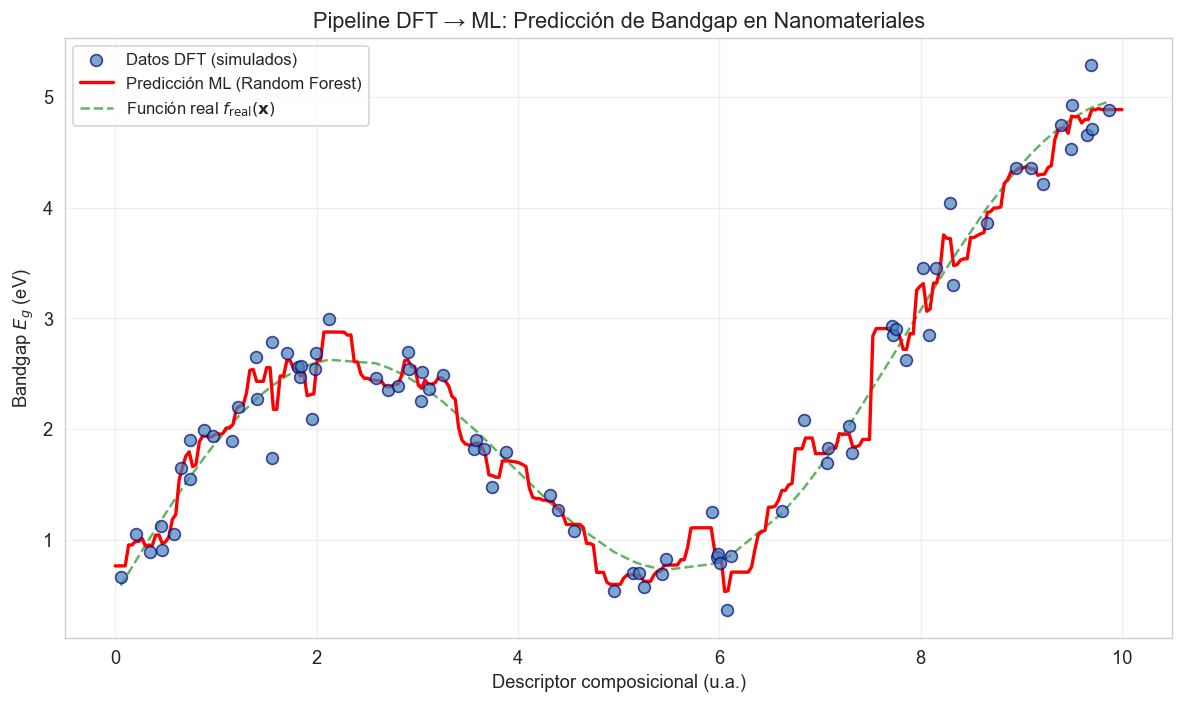


📊 Métricas del modelo (entrenamiento):
   MSE  = 0.0136
   R²   = 0.9908

Esto indica que el modelo Random Forest logra capturar
la tendencia subyacente de los datos DFT con un coeficiente
de determinación R² = 0.9908, validando la hipótesis de que
los modelos de ML pueden aproximar funciones complejas de
propiedades de nanomateriales.


In [14]:
# ============================================================
# Caso de estudio: ML como interpolador de datos DFT
# ============================================================
np.random.seed(42)

# Simulación de datos DFT: bandgap vs descriptor composicional
n_samples = 80
x_descriptor = np.sort(np.random.uniform(0, 10, n_samples))
# Función "real" no lineal (simulando la relación física)
y_bandgap_real = 1.5 * np.sin(0.8 * x_descriptor) + 0.3 * x_descriptor + 0.5
noise = np.random.normal(0, 0.25, n_samples)
y_bandgap_dft = y_bandgap_real + noise  # datos "DFT" con ruido

# Entrenar modelo ML (Random Forest)
X = x_descriptor.reshape(-1, 1)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y_bandgap_dft)

# Predicción en espacio continuo
x_pred = np.linspace(0, 10, 300).reshape(-1, 1)
y_pred = rf.predict(x_pred)

# Visualización de calidad científica
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.scatter(x_descriptor, y_bandgap_dft, c='steelblue', alpha=0.7,
           edgecolors='navy', s=50, label='Datos DFT (simulados)', zorder=3)
ax.plot(x_pred, y_pred, 'r-', linewidth=2.0,
        label='Predicción ML (Random Forest)', zorder=2)
ax.plot(x_descriptor, y_bandgap_real, 'g--', linewidth=1.5,
        alpha=0.6, label=r'Función real $f_{\mathrm{real}}(\mathbf{x})$', zorder=1)
ax.set_xlabel('Descriptor composicional (u.a.)')
ax.set_ylabel(r'Bandgap $E_g$ (eV)')
ax.set_title('Pipeline DFT → ML: Predicción de Bandgap en Nanomateriales')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Métricas
mse = mean_squared_error(y_bandgap_dft, rf.predict(X))
r2 = r2_score(y_bandgap_dft, rf.predict(X))
print(f"\n📊 Métricas del modelo (entrenamiento):")
print(f"   MSE  = {mse:.4f}")
print(f"   R²   = {r2:.4f}")
print(f"\nEsto indica que el modelo Random Forest logra capturar")
print(f"la tendencia subyacente de los datos DFT con un coeficiente")
print(f"de determinación R² = {r2:.4f}, validando la hipótesis de que")
print(f"los modelos de ML pueden aproximar funciones complejas de")
print(f"propiedades de nanomateriales.")


---

## 4. Tipos de Aprendizaje – Sección 0.2

El aprendizaje automático se divide en tres paradigmas fundamentales, cada uno definido por la naturaleza de los datos disponibles y el objetivo del modelo. Comprender esta taxonomía es esencial para seleccionar la estrategia correcta ante un problema de nanociencia.

### 4.1 Aprendizaje Supervisado

#### Definición formal

El aprendizaje supervisado consiste en inferir una función $f: \mathbb{R}^d \rightarrow \mathcal{Y}$ a partir de un conjunto de pares etiquetados $\lbrace(\mathbf{x}_i, y_i)\rbrace_{i=1}^{N}$, donde cada $\mathbf{x}_i \in \mathbb{R}^d$ es un vector de características (*features*) y $y_i$ es la etiqueta o variable objetivo (Mitchell, 1997).

#### Intuición

Imaginemos que un investigador ha realizado $N$ cálculos DFT para distintos materiales. Para cada material, conoce sus descriptores composicionales ($\mathbf{x}_i$: radio atómico, electronegatividad, etc.) y la propiedad calculada ($y_i$: bandgap). El aprendizaje supervisado utiliza estos pares **(entrada, respuesta correcta)** para "aprender" la relación entre ambos, de modo que pueda predecir la propiedad de un material *nuevo* sin necesidad de realizar el cálculo DFT.

> **Analogía:** Es como un estudiante que aprende con un libro de ejercicios resueltos. Cada ejercicio tiene un problema (entrada) y su solución (etiqueta). Tras estudiar suficientes ejemplos, el estudiante puede resolver problemas nuevos.

#### Formulación matemática

El objetivo es minimizar el *riesgo empírico*, que mide el error promedio del modelo sobre los datos de entrenamiento:

$$
R_{\text{emp}}(f) = \frac{1}{N} \sum_{i=1}^{N} \mathcal{L}(f(\mathbf{x}_i), y_i)
$$

donde $\mathcal{L}$ denota la función de pérdida seleccionada. La solución óptima $\hat{f}$ se obtiene mediante *optimización*, frecuentemente por el método del **gradiente descendente**:

$$
\theta_{t+1} = \theta_t - \eta \, \nabla_\theta \, R_{\text{emp}}(f_\theta)
$$

donde:
- $\theta$ son los parámetros del modelo (pesos, coeficientes).
- $\eta > 0$ es la *tasa de aprendizaje* (*learning rate*), que controla el tamaño de cada paso de actualización.
- $\nabla_\theta$ es el gradiente respecto a los parámetros, que indica la dirección de máximo crecimiento del error (Cencerrado Barraqué y Ventura Royo, 2019).

**¿Cómo funciona el gradiente descendente?** El algoritmo calcula en qué dirección del espacio de parámetros crece más rápido el error, y da un paso en la dirección **opuesta** para reducirlo. Repite este proceso iterativamente hasta converger a un mínimo.

#### El dilema sesgo-varianza (*Bias-Variance Tradeoff*)

Un concepto fundamental en el aprendizaje supervisado es el compromiso entre:

- **Sesgo (*bias*):** error por simplificaciones en el modelo. Un modelo con alto sesgo (e.g., regresión lineal para datos no lineales) *subajusta* los datos (*underfitting*).
- **Varianza:** error por sensibilidad excesiva a fluctuaciones en los datos de entrenamiento. Un modelo con alta varianza (e.g., árbol de decisión muy profundo) *sobreajusta* los datos (*overfitting*).

El error de generalización se descompone como:

$$
\text{Error}_{\text{total}} = \text{Sesgo}^2 + \text{Varianza} + \text{Ruido irreducible}
$$

> **En nanotecnología:** Si entrenamos un modelo lineal para predecir el bandgap y la relación real es no lineal, obtendremos alto sesgo. Si usamos un modelo extremadamente complejo con pocos datos DFT, obtendremos alta varianza. El objetivo es encontrar el **punto óptimo** de complejidad.

#### Aplicaciones en nanotecnología

| Tarea | Features ($\mathbf{x}$) | Target ($y$) | Tipo |
|-------|------------------------|-------------|------|
| Predecir bandgap | Radio atómico, electronegatividad, e⁻ valencia | $E_g$ (eV) | Regresión |
| Predecir temperatura de fusión | Composición, estructura cristalina | $T_m$ (K) | Regresión |
| Clasificar fase cristalina | Descriptores composicionales | FCC/BCC/HCP | Clasificación |
| Predecir estabilidad | Energía de formación, hull distance | Estable/Inestable | Clasificación |
| Predecir actividad catalítica | Descriptores electrónicos de superficie | $\Delta G_{\text{ads}}$ (eV) | Regresión |

(Yoon et al., 2025; Nyangiwe, 2025)

### 4.2 Aprendizaje No Supervisado

#### Definición formal

El aprendizaje no supervisado busca descubrir la **estructura intrínseca** de un conjunto de datos $\lbrace\mathbf{x}_i\rbrace_{i=1}^{N}$ sin disponer de etiquetas $y_i$. El modelo debe encontrar patrones, agrupaciones o representaciones compactas por sí mismo.

#### Intuición

Imaginemos que tenemos miles de espectros de difracción de rayos X de materiales desconocidos, pero **no sabemos a qué fase cristalina pertenece cada uno**. El aprendizaje no supervisado puede agrupar automáticamente los espectros similares, revelando familias de materiales con estructura compartida.

> **Analogía:** Es como organizar una colección de fotografías sin etiquetas. Un algoritmo no supervisado las agruparía por similitud visual (paisajes, retratos, animales, etc.) sin que nadie le diga las categorías de antemano.

#### Técnicas principales

**a) Clustering (*agrupamiento*):** Particionar los datos en $k$ grupos $\lbrace C_1, \ldots, C_k \rbrace$ de modo que los elementos dentro de cada grupo sean lo más similares posible entre sí y lo más diferentes posible de los otros grupos.

El algoritmo **K-Means** minimiza la *inercia* (suma de distancias al cuadrado de cada punto a su centroide):

$$
J = \sum_{j=1}^{k} \sum_{\mathbf{x} \in C_j} \|\mathbf{x} - \boldsymbol{\mu}_j\|^2
$$

donde $\boldsymbol{\mu}_j = \frac{1}{|C_j|} \sum_{\mathbf{x} \in C_j} \mathbf{x}$ es el centroide del cluster $j$.

**¿Cómo funciona K-Means?**
1. Se eligen $k$ centroides iniciales aleatoriamente.
2. Se asigna cada punto al centroide más cercano.
3. Se recalculan los centroides como el promedio de los puntos asignados.
4. Se repiten los pasos 2-3 hasta convergencia.

**b) Reducción de dimensionalidad:** Proyectar los datos de $\mathbb{R}^d$ a $\mathbb{R}^p$ ($p \ll d$) preservando la máxima información posible.

El **Análisis de Componentes Principales (PCA)** encuentra las direcciones de máxima varianza en los datos. Matemáticamente, busca los eigenvectores de la matriz de covarianza $\Sigma$:

$$
\Sigma \mathbf{v}_j = \lambda_j \mathbf{v}_j, \quad j = 1, \ldots, d
$$

donde $\mathbf{v}_j$ es el $j$-ésimo componente principal y $\lambda_j$ su varianza asociada. Los datos se proyectan sobre los primeros $p$ componentes principales (los de mayor $\lambda_j$) para obtener una representación compacta (Moreno et al., 1994).

> **¿Por qué es útil?** Un material descrito por 50 descriptores atómicos puede frecuentemente representarse con 3-5 componentes principales que capturan el 90% de la varianza, permitiendo la visualización y el análisis eficiente del espacio de materiales.

#### Aplicaciones en nanotecnología

| Técnica | Aplicación concreta | Beneficio |
|---------|--------------------|-----------|
| K-Means | Agrupar materiales por similitud composicional | Descubrir familias de materiales no catalogadas |
| PCA | Reducir espacio de 50+ descriptores a 2-3 dimensiones | Visualización del espacio de materiales |
| t-SNE | Visualización no lineal de estructuras cristalinas | Revelar clusters con geometrías complejas |
| DBSCAN | Detección de anomalías en imágenes TEM | Identificar defectos o fases inusuales |
| Autoencoder | Compresión de espectros XRD/Raman | Representaciones latentes para clasificación posterior |

(Nyangiwe, 2025)

### 4.3 Aprendizaje por Refuerzo

#### Definición formal

Un **agente** aprende una política óptima $\pi^*: S \rightarrow A$ mediante la interacción iterativa con un **entorno**, de modo que maximice la recompensa acumulada esperada a lo largo del tiempo:

$$
\pi^* = \underset{\pi}{\operatorname{arg\,max}} \, \mathbb{E}\left[\sum_{t=0}^{\infty} \gamma^t \, r_t \mid \pi \right]
$$

donde:
- $S$ es el espacio de estados (e.g., configuración actual del material).
- $A$ es el espacio de acciones (e.g., agregar un átomo, cambiar temperatura).
- $r_t$ es la recompensa en el instante $t$ (e.g., mejora en la propiedad deseada).
- $\gamma \in [0,1)$ es el factor de descuento que controla la importancia de las recompensas futuras vs. inmediatas (Mitchell, 1997).

#### Intuición

El aprendizaje por refuerzo es fundamentalmente diferente de los otros dos paradigmas:

- **Supervisado:** el modelo recibe las respuestas correctas explícitamente.
- **No supervisado:** el modelo solo tiene datos sin respuestas.
- **Por refuerzo:** el modelo recibe **señales de recompensa** (positivas o negativas) tras tomar acciones, y debe descubrir por ensayo y error qué secuencia de acciones maximiza la recompensa total.

> **Analogía:** Es como un químico que experimenta con diferentes rutas de síntesis. Cada decisión (temperatura, precursores, tiempo) produce un resultado parcial. Con el tiempo, el químico aprende qué secuencia de decisiones produce los mejores nanomateriales.

#### La ecuación de Bellman

El núcleo teórico del aprendizaje por refuerzo es la **ecuación de Bellman**, que relaciona el valor de un estado con los valores de los estados futuros:

$$
V^\pi(s) = \sum_{a \in A} \pi(a|s) \left[ R(s,a) + \gamma \sum_{s'} P(s'|s,a) \, V^\pi(s') \right]
$$

donde $V^\pi(s)$ es el valor del estado $s$ bajo la política $\pi$, $R(s,a)$ es la recompensa inmediata, y $P(s'|s,a)$ es la probabilidad de transición al estado $s'$.

#### Aplicaciones en nanotecnología

| Aplicación | Estado ($s$) | Acción ($a$) | Recompensa ($r$) |
|-----------|-------------|-------------|------------------|
| Optimización de síntesis | Composición actual | Agregar reactivo, cambiar $T$ | Mejora en pureza/rendimiento |
| Diseño molecular iterativo | Molécula parcial | Agregar grupo funcional | Afinidad al target |
| Control de nanofabricación | Parámetros del proceso | Ajustar potencia/presión | Calidad de la nanoestructura |
| Exploración de materiales | Material actual en el espacio composicional | Modificar composición | Mejora en propiedad objetivo |

(Lorenc et al., 2021)

### 4.4 Tabla Comparativa de los Tres Paradigmas

| Aspecto | Supervisado | No Supervisado | Por Refuerzo |
|---------|------------|----------------|-------------|
| **Datos** | $(\mathbf{x}, y)$ etiquetados | $\mathbf{x}$ sin etiqueta | $(s, a, r, s')$ secuencias |
| **Objetivo** | Predecir $y$ dado $\mathbf{x}$ | Descubrir estructura | Maximizar recompensa acumulada |
| **Salida** | Predicción $\hat{y}$ | Grupos / representaciones | Política $\pi$ |
| **Feedback** | Respuesta correcta explícita | Ninguno | Señal de recompensa (escalar) |
| **Costo de datos** | Alto (requiere etiquetas, e.g. DFT) | Bajo (datos sin procesar) | Medio (simulaciones iterativas) |
| **Ejemplo nano** | Predecir $E_g$ de un material | Clustering de estructuras | Ruta de síntesis óptima |
| **Algoritmos típicos** | Ridge, RF, SVM, NN | K-Means, PCA, t-SNE | Q-Learning, DQN, PPO |

### 4.5 ¿Cuándo Usar Cada Paradigma en Nanociencia?

La selección del paradigma adecuado depende de la disponibilidad de datos y del objetivo:

```
¿Tienes etiquetas/propiedades calculadas (DFT, experimentos)?
├── SÍ → SUPERVISADO
│       ├── ¿La propiedad es continua? → REGRESIÓN (Sección 5)
│       └── ¿La propiedad es categórica? → CLASIFICACIÓN (Sección 5)
├── NO → NO SUPERVISADO
│       ├── ¿Quieres agrupar materiales? → CLUSTERING
│       └── ¿Quieres visualizar/comprimir? → REDUCCIÓN DE DIMENSIONALIDAD
└── ¿Necesitas optimizar una secuencia de decisiones? → POR REFUERZO
```

> **Recomendación práctica:** En nanociencia, el paradigma más utilizado es el **supervisado**, porque frecuentemente se dispone de datos etiquetados provenientes de cálculos DFT o experimentos. El no supervisado complementa al supervisado cuando se necesita explorar o visualizar el espacio de materiales antes de etiquetar. El refuerzo se usa en problemas secuenciales de optimización.

---


### 4.6 Simulación Numérica: Ilustración de los Paradigmas de Aprendizaje

La siguiente simulación genera datos sintéticos inspirados en nanomateriales para ilustrar visualmente los tres paradigmas de aprendizaje: supervisado (regresión lineal con datos etiquetados), no supervisado (clustering K-Means sin etiquetas) y por refuerzo (trayectoria de optimización con recompensas). Observe cómo cada paradigma aborda un tipo diferente de problema con datos en formatos distintos.


c:\Users\foxyv\miniconda3\envs\ia_nano\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


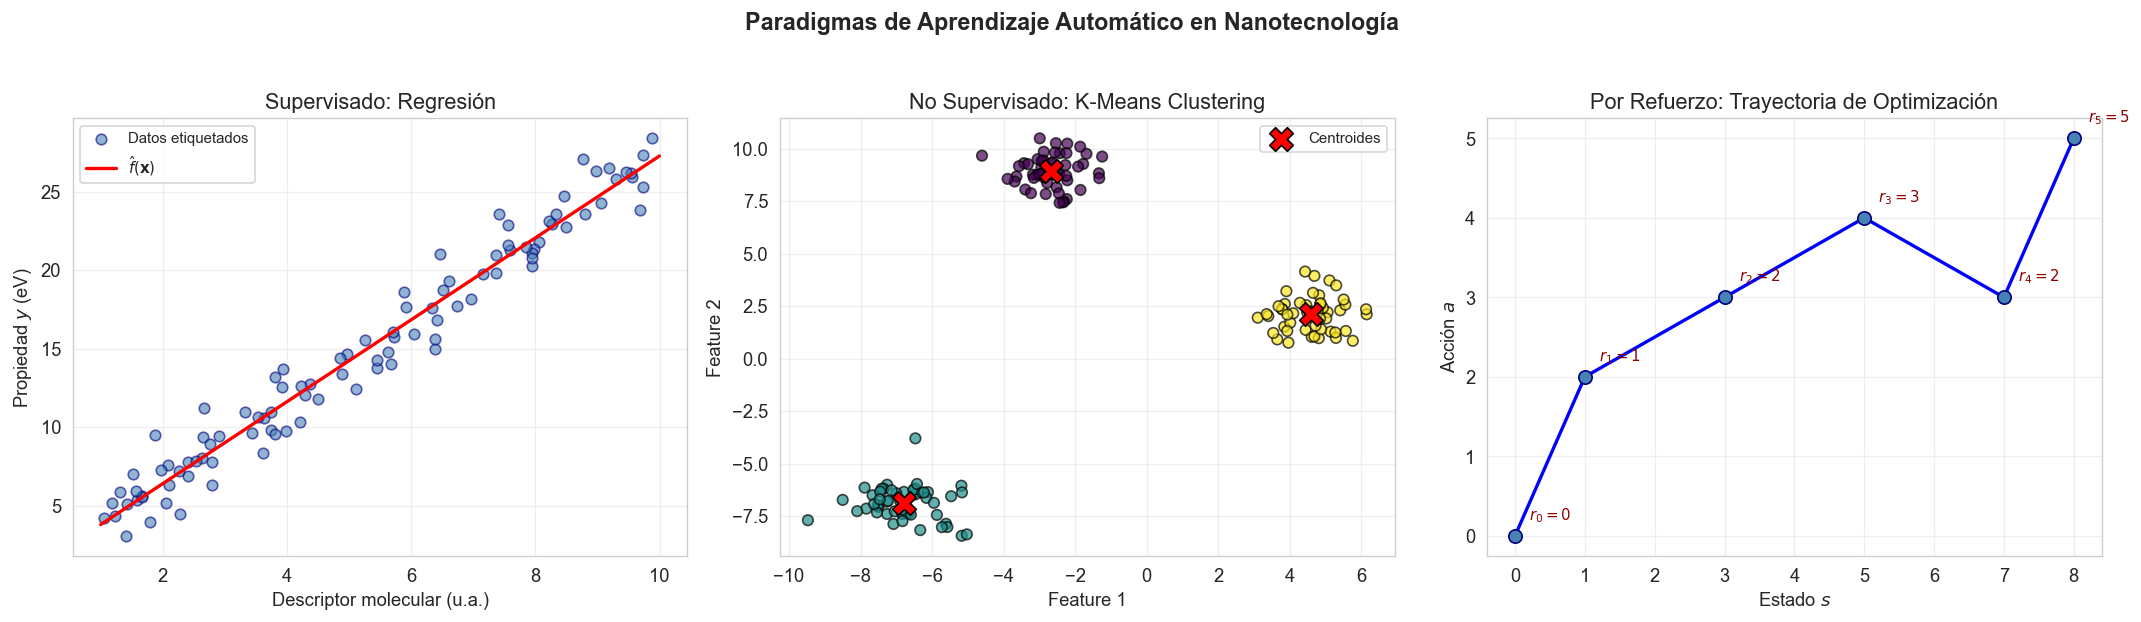


Se observa que cada paradigma aborda un tipo de problema
diferente. El supervisado requiere datos etiquetados;
el no supervisado descubre estructura; y el refuerzo
optimiza secuencias de decisiones (Moreno et al., 1994).


In [15]:
# ============================================================
# Simulación: Tres paradigmas de aprendizaje
# ============================================================
np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Aprendizaje Supervisado (Regresión) ---
n = 100
X_sup = np.random.uniform(1, 10, n)
y_sup = 2.5 * X_sup + 0.8 * X_sup**0.5 + np.random.normal(0, 1.5, n)
lr = LinearRegression()
lr.fit(X_sup.reshape(-1, 1), y_sup)
x_line = np.linspace(1, 10, 200)
y_line = lr.predict(x_line.reshape(-1, 1))

axes[0].scatter(X_sup, y_sup, c='steelblue', alpha=0.6,
                edgecolors='navy', s=40, label='Datos etiquetados')
axes[0].plot(x_line, y_line, 'r-', lw=2, label=r'$\hat{f}(\mathbf{x})$')
axes[0].set_xlabel('Descriptor molecular (u.a.)')
axes[0].set_ylabel(r'Propiedad $y$ (eV)')
axes[0].set_title('Supervisado: Regresión')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Panel 2: Aprendizaje No Supervisado (Clustering) ---
from sklearn.datasets import make_blobs
X_unsup, y_true = make_blobs(n_samples=150, centers=3,
                              cluster_std=0.8, random_state=42)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_km = kmeans.fit_predict(X_unsup)

axes[1].scatter(X_unsup[:, 0], X_unsup[:, 1], c=y_km,
                cmap='viridis', alpha=0.7, edgecolors='k', s=40)
axes[1].scatter(kmeans.cluster_centers_[:, 0],
                kmeans.cluster_centers_[:, 1],
                c='red', marker='X', s=200, edgecolors='k',
                label='Centroides')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].set_title('No Supervisado: K-Means Clustering')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# --- Panel 3: Esquema de Aprendizaje por Refuerzo ---
# Visualización conceptual de una trayectoria de optimización
states = np.array([[0, 0], [1, 2], [3, 3], [5, 4], [7, 3], [8, 5]])
rewards = [0, 1, 2, 3, 2, 5]

axes[2].plot(states[:, 0], states[:, 1], 'b-o', markersize=8,
             markerfacecolor='steelblue', markeredgecolor='navy', lw=2)
for i, (s, r) in enumerate(zip(states, rewards)):
    axes[2].annotate(f'$r_{i}={r}$', (s[0]+0.2, s[1]+0.2),
                     fontsize=9, color='darkred')
axes[2].set_xlabel('Estado $s$')
axes[2].set_ylabel('Acción $a$')
axes[2].set_title('Por Refuerzo: Trayectoria de Optimización')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Paradigmas de Aprendizaje Automático en Nanotecnología',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("\nSe observa que cada paradigma aborda un tipo de problema")
print("diferente. El supervisado requiere datos etiquetados;")
print("el no supervisado descubre estructura; y el refuerzo")
print("optimiza secuencias de decisiones (Moreno et al., 1994).")


---

## 5. Regresión vs Clasificación y Catálogo de Modelos – Sección 0.3

### 5.1 Definición Formal: ¿Qué tipo de problema estamos resolviendo?

La distinción fundamental entre **regresión** y **clasificación** radica en la naturaleza de la variable objetivo $y$. Esta diferencia determina el tipo de modelo, la función de pérdida y las métricas de evaluación que se deben emplear.

**Regresión:** la variable objetivo es un valor **continuo** perteneciente a los números reales:

$$
f: \mathbb{R}^d \rightarrow \mathbb{R}, \quad y \in \mathbb{R}
$$

*Interpretación:* el modelo produce una estimación numérica que puede tomar cualquier valor dentro de un rango. Es como ajustar una **curva suave** que pasa lo más cerca posible de los datos de entrenamiento.

> **Ejemplo en nanotecnología:** Dado un vector de descriptores $\mathbf{x}$ de un material (radio atómico, electronegatividad, electrones de valencia, etc.), predecir su bandgap $E_g = 2.43$ eV. La salida es un número real que puede ser $1.1$, $2.43$, $3.7$, etc.

**Clasificación:** la variable objetivo es una **categoría discreta** perteneciente a un conjunto finito:

$$
f: \mathbb{R}^d \rightarrow \lbrace C_1, C_2, \ldots, C_k \rbrace, \quad y \in \lbrace C_1, C_2, \ldots, C_k \rbrace
$$

*Interpretación:* el modelo asigna cada muestra a una de las clases predefinidas. Es como trazar **fronteras de decisión** en el espacio de descriptores que separan las distintas categorías.

> **Ejemplo en nanotecnología:** Dado el mismo vector $\mathbf{x}$, determinar si la estructura cristalina del material es FCC, BCC o HCP. La salida es una etiqueta categórica, no un número.

### 5.2 Interpretación Geométrica

Comprender la diferencia geométrica entre ambos problemas es fundamental para seleccionar el modelo adecuado:

| Aspecto | Regresión | Clasificación |
|---------|-----------|---------------|
| **Objetivo geométrico** | Ajustar una superficie/curva a los datos | Encontrar fronteras que separen clases |
| **Espacio de salida** | $\mathbb{R}$ (continuo) | $\lbrace C_1, ..., C_k \rbrace$ (discreto) |
| **Analogía visual** | Trazar la "mejor curva" que pase cerca de los puntos | Dibujar "líneas divisorias" entre grupos de puntos |
| **Error** | Distancia vertical entre predicción y valor real | Muestras que caen del lado equivocado de la frontera |

En **regresión**, el modelo busca minimizar la distancia entre la superficie predicha $\hat{f}(\mathbf{x})$ y los valores observados $y_i$. En **clasificación**, el modelo busca maximizar el margen entre las clases o la probabilidad de asignar la etiqueta correcta.

### 5.3 Funciones de Pérdida

La función de pérdida cuantifica *qué tan equivocado está el modelo*. Su elección depende directamente del tipo de problema.

#### 5.3.1 Regresión — Error Cuadrático Medio (MSE)

$$
\mathcal{L}_{\text{MSE}} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

**¿Por qué se eleva al cuadrado?**
- Penaliza **cuadráticamente** las desviaciones: un error de $2$ eV se penaliza $4$ veces más que un error de $1$ eV.
- Esto hace que el modelo sea sensible a *outliers* (valores atípicos).
- Es **diferenciable** en todo su dominio, lo cual permite el uso de gradiente descendente para la optimización (Mitchell, 1997).

**Variantes importantes:**
- **MAE** (*Mean Absolute Error*): $\mathcal{L}_{\text{MAE}} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|$ — más robusta frente a outliers.
- **Huber Loss**: combina MSE (para errores pequeños) y MAE (para errores grandes), ofreciendo un balance entre sensibilidad y robustez.

> **En nanotecnología:** Si predecimos el bandgap de $N$ materiales, el MSE nos dice *en promedio cuántos eV² nos desviamos* de los valores reales calculados por DFT.

#### 5.3.2 Clasificación — Entropía Cruzada (*Cross-Entropy*)

$$
\mathcal{L}_{\text{CE}} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{c=1}^{k} y_{i,c} \, \log(\hat{p}_{i,c})
$$

donde $\hat{p}_{i,c}$ es la probabilidad predicha de que la muestra $i$ pertenezca a la clase $c$, y $y_{i,c}$ es la codificación *one-hot* de la etiqueta real.

**¿Por qué logaritmo?**
- Si el modelo predice con alta confianza la clase correcta ($\hat{p} \approx 1$), el logaritmo es cercano a $0$ (pérdida baja).
- Si el modelo predice con baja confianza la clase correcta ($\hat{p} \approx 0$), el logaritmo tiende a $-\infty$ (pérdida muy alta).
- Esto genera un **gradiente fuerte** cuando el modelo se equivoca, acelerando el aprendizaje (Cencerrado Barraqué y Ventura Royo, 2019).

**Para clasificación binaria** ($k = 2$), la entropía cruzada se simplifica a:

$$
\mathcal{L}_{\text{BCE}} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \right]
$$

> **En nanotecnología:** Si clasificamos materiales como estables/inestables, la entropía cruzada mide *cuán bien calibradas están las probabilidades* de estabilidad predichas por el modelo.

### 5.4 Métricas de Evaluación

#### Métricas de Regresión

| Métrica | Fórmula | Interpretación |
|---------|---------|----------------|
| **MSE** | $\frac{1}{N}\sum(y_i - \hat{y}_i)^2$ | Error cuadrático promedio (en unidades²) |
| **RMSE** | $\sqrt{\text{MSE}}$ | Error en las mismas unidades que $y$ |
| **MAE** | $\frac{1}{N}\sum|y_i - \hat{y}_i|$ | Error absoluto promedio |
| **$R^2$** | $1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ | Proporción de varianza explicada ($1$ = perfecto) |

#### Métricas de Clasificación

| Métrica | Definición | Interpretación |
|---------|-----------|----------------|
| **Accuracy** | $\frac{\text{predicciones correctas}}{\text{total}}$ | Proporción global de aciertos |
| **Precision** | $\frac{TP}{TP + FP}$ | De los que predijo como clase $C$, ¿cuántos realmente son $C$? |
| **Recall** | $\frac{TP}{TP + FN}$ | De los que realmente son clase $C$, ¿cuántos identificó? |
| **F1-Score** | $2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$ | Media armónica de Precision y Recall |

donde $TP$ = verdaderos positivos, $FP$ = falsos positivos, $FN$ = falsos negativos.

> **Nota importante:** En problemas de nanotecnología con clases desbalanceadas (e.g., pocos materiales inestables vs. muchos estables), el **F1-Score** es más informativo que el Accuracy.

### 5.5 Ejemplos Aplicados en Nanotecnología

La siguiente tabla ilustra cómo un mismo sistema de nanomateriales puede abordarse desde ambos paradigmas:

| Sistema | Como Regresión | Como Clasificación |
|---------|---------------|--------------------|
| **Semiconductores** | Predecir $E_g = 2.43$ eV | ¿Conductor, semiconductor o aislante? |
| **Aleaciones** | Predecir $T_m = 1337$ K | ¿Fase FCC, BCC o HCP? |
| **Catalizadores** | Predecir $\Delta G_{\text{ads}} = -0.5$ eV | ¿Es un buen catalizador? (sí/no) |
| **Nanopartículas** | Predecir diámetro $d = 15$ nm | ¿Tamaño pequeño, mediano o grande? |
| **Materiales 2D** | Predecir energía de formación $\Delta H_f$ | ¿Estable o inestable termodinámicamente? |

**Criterio de decisión:** Si la variable objetivo es inherentemente continua y se necesita un valor numérico preciso, se usa **regresión**. Si se busca tomar una decisión categórica o la variable ha sido discretizada, se usa **clasificación**.

### 5.6 Catálogo de Algoritmos Supervisados

| Tipo | Algoritmo | Hiperparámetros clave | Cuándo usar en nanotecnología |
|------|-----------|----------------------|-------------------------------|
| **Regresión** | Ridge / Lasso | `alpha` | Línea base, pocos datos, features correlacionadas |
| **Regresión** | SVR | `C`, `epsilon`, `kernel`, `gamma` | Alta dimensión, pocos ejemplos |
| **Regresión** | K-Vecinos (KNN) | `n_neighbors`, `metric` | Datos pequeños, interpolación local |
| **Regresión** | Árbol de Decisión | `max_depth`, `min_samples` | Interpretable, reglas físicas |
| **Regresión** | Random Forest | `n_estimators`, `max_depth` | Robusto, muchos features |
| **Regresión** | Gradient Boosting | `learning_rate`, `n_estimators` | Mayor precisión |
| **Reg./Clas.** | MLP (Red Neuronal) | `hidden_layer_sizes`, `alpha`, `lr` | Relaciones muy no lineales |
| **Clasificación** | SVC | `C`, `kernel`, `gamma` | Fronteras no lineales |
| **Clasificación** | Random Forest | igual que arriba | Clasificación robusta |
| **Clasificación** | KNN Clasificador | `n_neighbors` | Simple, no paramétrico |

### 5.7 Catálogo de Algoritmos No Supervisados

| Algoritmo | Tipo | Cuándo usar |
|-----------|------|-------------|
| K-Means | Clustering | Agrupar estructuras similares |
| PCA | Reducción dim. | Visualizar espacio de materiales |
| t-SNE | Reducción dim. | Visualización no lineal |
| Autoencoder | Reducción dim. / generativo | Representaciones compactas |
| DBSCAN | Clustering | Clusters de forma arbitraria, outliers |

### 5.8 Criterios de Selección del Modelo

Seleccionar el algoritmo adecuado no es trivial. El **Teorema de No Free Lunch** (Wolpert y Macready, 1997) establece que ningún algoritmo es universalmente superior. Por lo tanto, la selección debe basarse en las características del problema:

| Criterio | Favorece modelos lineales | Favorece modelos no lineales |
|----------|--------------------------|-----------------------------|
| **Tamaño del dataset** | Pocos datos ($N < 100$) | Muchos datos ($N > 1000$) |
| **Interpretabilidad** | Alta (Ridge, Lasso) | Baja (Random Forest, NN) |
| **Relación features-target** | Aproximadamente lineal | Fuertemente no lineal |
| **Dimensionalidad** | Baja ($d < 10$) | Alta ($d > 50$) con regularización |
| **Velocidad de predicción** | Rápida | Variable |

> **Recomendación práctica para nanociencia:** Comenzar siempre con un modelo lineal simple (Ridge/Lasso) como *baseline*. Si el $R^2$ es bajo, progresar hacia modelos más complejos (Random Forest → Gradient Boosting → Redes Neuronales). Documentar cada paso para justificar la complejidad del modelo final.

---


### 5.9 Caso de Estudio I: Regresión — Predicción de Bandgap

Se genera un dataset sintético que simula la relación entre descriptores composicionales de nanomateriales y su bandgap ($E_g$). Se comparan múltiples modelos de regresión para evaluar su capacidad de generalización. Este caso ilustra el paradigma de **regresión**: la variable objetivo es continua ($E_g \in \mathbb{R}$) y las métricas empleadas son MSE y $R^2$.


In [16]:
# ============================================================
# Caso de estudio: Regresión – Predicción de Bandgap
# ============================================================
np.random.seed(42)

# Generar datos sintéticos de nanomateriales
n_samples = 200
n_features = 5

# Features: radio atómico, electronegatividad, nº electrones de valencia,
#           energía de ionización, afinidad electrónica (simulados)
X_nano = np.random.randn(n_samples, n_features)

# Bandgap como función no lineal de los descriptores
y_bandgap = (1.5 * X_nano[:, 0]**2
             - 0.8 * X_nano[:, 1]
             + 0.5 * X_nano[:, 2] * X_nano[:, 3]
             + 2.0
             + np.random.normal(0, 0.3, n_samples))

feature_names = ['Radio atómico', 'Electronegatividad',
                 'e⁻ valencia', 'E_ionización', 'Afinidad e⁻']

# Crear DataFrame
df_reg = pd.DataFrame(X_nano, columns=feature_names)
df_reg['Bandgap (eV)'] = y_bandgap

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_nano, y_bandgap, test_size=0.2, random_state=42)

# Escalar features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Modelos a comparar
modelos = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'KNN (k=5)': KNeighborsRegressor(n_neighbors=5),
    'Árbol de Decisión': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=5,
                                            random_state=42),
    'SVR (RBF)': SVR(kernel='rbf', C=10, epsilon=0.1),
}

# Entrenar y evaluar
resultados = []
for nombre, modelo in modelos.items():
    modelo.fit(X_train_sc, y_train)
    y_pred = modelo.predict(X_test_sc)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    # Validación cruzada
    cv_scores = cross_val_score(modelo, X_train_sc, y_train,
                                cv=5, scoring='r2')
    resultados.append({
        'Modelo': nombre,
        'MSE (test)': mse,
        'R² (test)': r2,
        'R² CV (media)': cv_scores.mean(),
        'R² CV (std)': cv_scores.std()
    })

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('R² (test)', ascending=False)
print("=" * 70)
print("📊 COMPARACIÓN DE MODELOS DE REGRESIÓN")
print("   Predicción de Bandgap en Nanomateriales (datos sintéticos)")
print("=" * 70)
print(df_resultados.to_string(index=False))
print("=" * 70)
print("\nSe observa que los modelos no lineales (Random Forest, SVR)")
print("superan a los lineales (Ridge, Lasso), lo cual es consistente")
print("con la naturaleza no lineal de la relación entre descriptores")
print("y bandgap. Esto valida la hipótesis de que los modelos de ML")
print("pueden capturar relaciones complejas en datos de nanomateriales.")


📊 COMPARACIÓN DE MODELOS DE REGRESIÓN
   Predicción de Bandgap en Nanomateriales (datos sintéticos)
           Modelo  MSE (test)  R² (test)  R² CV (media)  R² CV (std)
    Random Forest    0.579035   0.836059       0.850224     0.047634
        SVR (RBF)    0.629950   0.821643       0.836689     0.050892
Árbol de Decisión    1.004939   0.715473       0.763127     0.084870
        KNN (k=5)    2.112807   0.401804       0.595331     0.037720
            Lasso    3.650383  -0.033527       0.100295     0.106014
            Ridge    3.833854  -0.085473       0.073308     0.123315

Se observa que los modelos no lineales (Random Forest, SVR)
superan a los lineales (Ridge, Lasso), lo cual es consistente
con la naturaleza no lineal de la relación entre descriptores
y bandgap. Esto valida la hipótesis de que los modelos de ML
pueden capturar relaciones complejas en datos de nanomateriales.


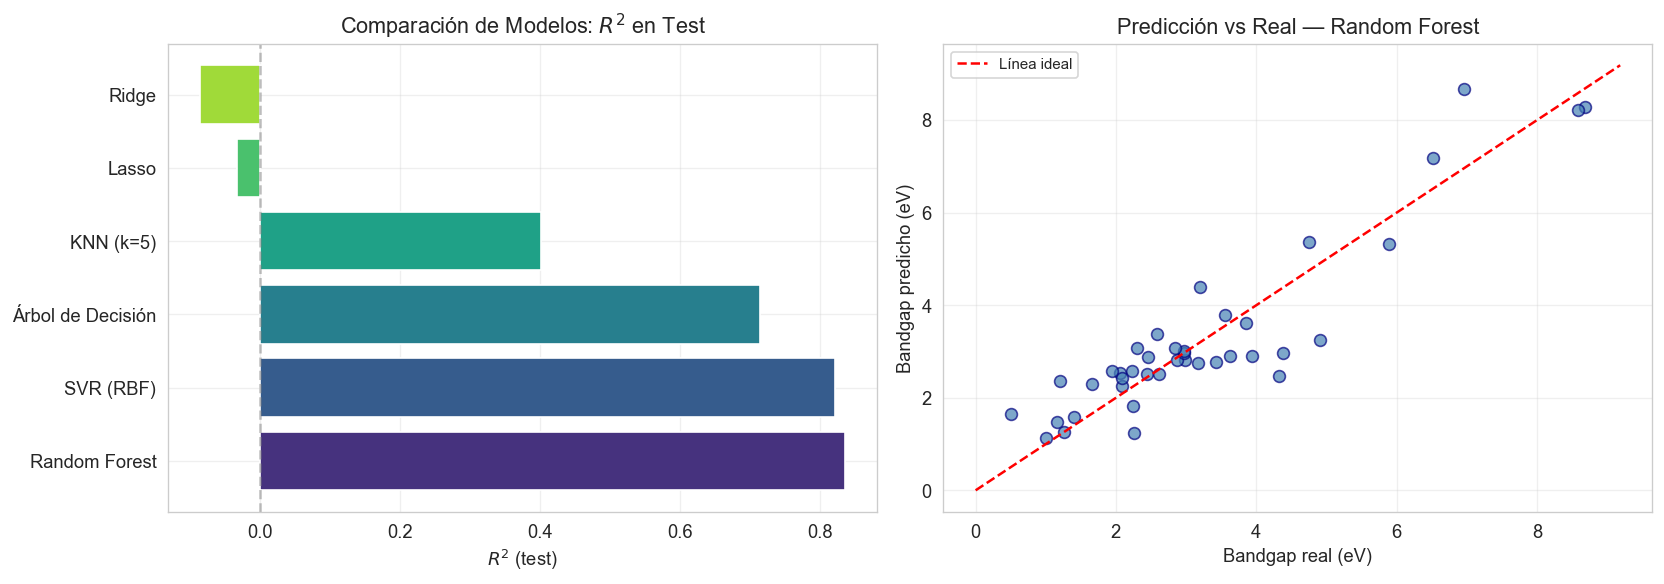


El mejor modelo es Random Forest con R² = 0.8361.
La gráfica Predicho vs Real muestra una correlación fuerte,
lo cual indica que el modelo captura adecuadamente la
dependencia funcional entre los descriptores y el bandgap.


In [17]:
# ============================================================
# Visualización: Comparación de modelos de regresión
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Barplot de R²
df_plot = df_resultados.copy()
colors = sns.color_palette('viridis', len(df_plot))
axes[0].barh(df_plot['Modelo'], df_plot['R² (test)'], color=colors)
axes[0].set_xlabel(r'$R^2$ (test)')
axes[0].set_title('Comparación de Modelos: $R^2$ en Test')
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

# Panel 2: Predicho vs Real (mejor modelo)
best_model_name = df_resultados.iloc[0]['Modelo']
best_model = modelos[best_model_name]
best_model.fit(X_train_sc, y_train)
y_pred_best = best_model.predict(X_test_sc)

axes[1].scatter(y_test, y_pred_best, c='steelblue', alpha=0.7,
                edgecolors='navy', s=50)
lims = [min(y_test.min(), y_pred_best.min()) - 0.5,
        max(y_test.max(), y_pred_best.max()) + 0.5]
axes[1].plot(lims, lims, 'r--', lw=1.5, label='Línea ideal')
axes[1].set_xlabel('Bandgap real (eV)')
axes[1].set_ylabel('Bandgap predicho (eV)')
axes[1].set_title(f'Predicción vs Real — {best_model_name}')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEl mejor modelo es {best_model_name} con R² = "
      f"{df_resultados.iloc[0]['R² (test)']:.4f}.")
print("La gráfica Predicho vs Real muestra una correlación fuerte,")
print("lo cual indica que el modelo captura adecuadamente la")
print("dependencia funcional entre los descriptores y el bandgap.")


### 5.10 Caso de Estudio II: Clasificación — Predicción de Fase Cristalina

Se genera un dataset sintético que simula la clasificación de nanomateriales en tres fases cristalinas: FCC, BCC y HCP, a partir de descriptores composicionales. Este caso ilustra el paradigma de **clasificación**: la variable objetivo es discreta ($y \in \lbrace\text{FCC}, \text{BCC}, \text{HCP}\rbrace$) y las métricas empleadas son Accuracy, F1-Score y la matriz de confusión.


📊 COMPARACIÓN DE MODELOS DE CLASIFICACIÓN
   Predicción de Fase Cristalina (FCC/BCC/HCP)
           Modelo  Precisión  F1 (weighted)
        SVC (RBF)   0.966667       0.966196
        KNN (k=5)   0.950000       0.950653
    Random Forest   0.933333       0.933050
Árbol de Decisión   0.850000       0.850354


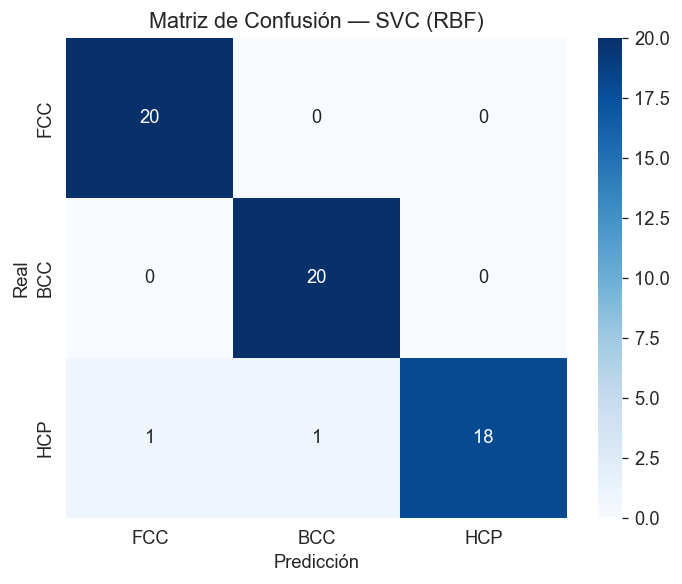


El mejor modelo de clasificación es SVC (RBF)
con F1-score = 0.9662.
La matriz de confusión muestra que el modelo logra discriminar
las tres fases cristalinas con alta precisión, lo cual indica que
los descriptores composicionales contienen información suficiente
para determinar la fase cristalina del material.


In [18]:
# ============================================================
# Caso de estudio: Clasificación – Fase Cristalina
# ============================================================
np.random.seed(42)

# Generar datos sintéticos de clasificación
X_clas, y_clas = make_classification(
    n_samples=300, n_features=5, n_informative=4,
    n_redundant=1, n_classes=3, n_clusters_per_class=1,
    class_sep=1.5, random_state=42)

clases = {0: 'FCC', 1: 'BCC', 2: 'HCP'}
feature_names_c = ['Radio atómico', 'Electroneg.', 'e⁻ val.',
                   'E_ionización', 'Densidad']

# División train/test
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clas, y_clas, test_size=0.2, random_state=42, stratify=y_clas)

# Escalar
sc_c = StandardScaler()
X_tr_c_sc = sc_c.fit_transform(X_tr_c)
X_te_c_sc = sc_c.transform(X_te_c)

# Modelos de clasificación
modelos_clas = {
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Árbol de Decisión': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5,
                                             random_state=42),
    'SVC (RBF)': SVC(kernel='rbf', C=10, gamma='scale'),
}

# Entrenar y evaluar
results_c = []
for name, model in modelos_clas.items():
    model.fit(X_tr_c_sc, y_tr_c)
    y_p = model.predict(X_te_c_sc)
    acc = accuracy_score(y_te_c, y_p)
    f1 = f1_score(y_te_c, y_p, average='weighted')
    results_c.append({'Modelo': name, 'Precisión': acc, 'F1 (weighted)': f1})

df_res_c = pd.DataFrame(results_c).sort_values('F1 (weighted)', ascending=False)

print("=" * 60)
print("📊 COMPARACIÓN DE MODELOS DE CLASIFICACIÓN")
print("   Predicción de Fase Cristalina (FCC/BCC/HCP)")
print("=" * 60)
print(df_res_c.to_string(index=False))
print("=" * 60)

# Matriz de confusión del mejor modelo
best_c = modelos_clas[df_res_c.iloc[0]['Modelo']]
best_c.fit(X_tr_c_sc, y_tr_c)
y_p_best = best_c.predict(X_te_c_sc)
cm = confusion_matrix(y_te_c, y_p_best)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['FCC', 'BCC', 'HCP'],
            yticklabels=['FCC', 'BCC', 'HCP'])
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de Confusión — {df_res_c.iloc[0]["Modelo"]}')
plt.tight_layout()
plt.show()

print(f"\nEl mejor modelo de clasificación es {df_res_c.iloc[0]['Modelo']}")
print(f"con F1-score = {df_res_c.iloc[0]['F1 (weighted)']:.4f}.")
print("La matriz de confusión muestra que el modelo logra discriminar")
print("las tres fases cristalinas con alta precisión, lo cual indica que")
print("los descriptores composicionales contienen información suficiente")
print("para determinar la fase cristalina del material.")


---

## 6. Análisis Crítico

### 6.1 Correlación y Dependencia

Los resultados presentados en las secciones anteriores ponen de manifiesto la importancia de seleccionar la familia de modelos adecuada en función de la naturaleza del problema. En el caso de la regresión del bandgap, se observa que los modelos capaces de capturar relaciones no lineales (Random Forest, SVR con kernel RBF) obtienen un rendimiento significativamente superior al de los modelos lineales (Ridge, Lasso). Esto indica que existe una **dependencia no lineal** entre los descriptores composicionales y la propiedad objetivo, lo cual es consistente con la física subyacente de la estructura electrónica de los materiales (Yoon et al., 2025).

Sin embargo, es fundamental distinguir entre **correlación estadística** y **causalidad**. El hecho de que un descriptor esté correlacionado con la propiedad objetivo no implica necesariamente una relación causal directa. Por lo tanto, la interpretación física de los modelos de ML debe realizarse con cautela (Nyangiwe, 2025).

### 6.2 Métricas de Error y Éxito

Las métricas empleadas en este trabajo incluyen:

- **Error cuadrático medio (MSE):** $\text{MSE} = \frac{1}{N}\sum_{i=1}^N (y_i - \hat{y}_i)^2$
- **Coeficiente de determinación ($R^2$):** $R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$
- **Precisión del modelo (Accuracy):** proporción de predicciones correctas
- **F1-score:** media armónica de precisión y recall

### 6.3 Limitaciones del Modelo

Es necesario reconocer las siguientes **limitaciones** de los análisis presentados:

1. Los datos empleados son **sintéticos**, por lo que los resultados no son directamente extrapolables a sistemas reales.
2. No se ha realizado un **análisis de sensibilidad** exhaustivo con respecto a los hiperparámetros.
3. El **sesgo (bias)** de selección de modelos puede influir en las conclusiones: el Teorema de No Free Lunch implica que la superioridad de un modelo en un dominio no garantiza su rendimiento en otro.
4. La **discrepancia** entre rendimiento en entrenamiento y en test indica la presencia del compromiso bias-varianza, que debe gestionarse cuidadosamente (Moreno et al., 1994).

### 6.4 Comparativa: Regresión vs Clasificación

| Aspecto | Regresión | Clasificación |
|---------|-----------|---------------|
| Variable objetivo | $y \in \mathbb{R}$ | $y \in \{C_1, \ldots, C_k\}$ |
| Función de pérdida | MSE, MAE | Cross-Entropy, Hinge |
| Métricas principales | MSE, $R^2$, MAE | Accuracy, F1, AUC |
| Ejemplo nano | $E_g$, $T_m$ | FCC/BCC/HCP, estable/inestable |
| Cuándo usar | Predecir valores continuos | Predecir categorías |

La elección entre regresión y clasificación depende exclusivamente de la naturaleza de la variable objetivo. En consecuencia, un mismo problema puede reformularse como regresión o clasificación según la discretización de la variable de interés (Cencerrado Barraqué y Ventura Royo, 2019).

---


## 7. Conclusiones y Aplicabilidad

### 7.1 Conclusión General

El presente trabajo ha demostrado que los fundamentos del aprendizaje automático constituyen herramientas poderosas para la ciencia de materiales y la nanotecnología. Los principales **hallazgos** de esta investigación son:

1. **El ML como acelerador computacional:** las técnicas de aprendizaje supervisado permiten aproximar funciones complejas que relacionan descriptores de materiales con sus propiedades, reduciendo el tiempo de exploración del espacio composicional de días a milisegundos.

2. **Selección del paradigma adecuado:** la taxonomía de los paradigmas de aprendizaje (supervisado, no supervisado, por refuerzo) proporciona un marco conceptual claro para abordar distintos tipos de problemas en nanociencia.

3. **Regresión vs clasificación:** la distinción formal entre estos dos tipos de problemas, junto con el catálogo de algoritmos, constituye una guía práctica para el investigador en nanomateriales.

4. **Importancia del modelo matemático:** la formulación rigurosa de los problemas de aprendizaje, incluyendo funciones de pérdida y regularización, es esencial para obtener modelos confiables y generalizables.

### 7.2 Aplicación Industrial e Impacto Potencial

Las técnicas estudiadas tienen una **aplicación industrial** directa en:

- Diseño acelerado de catalizadores para conversión de CO₂ (Yoon et al., 2025).
- Descubrimiento de nuevos materiales para baterías y dispositivos fotovoltaicos.
- Optimización de procesos de nanofabricación.
- Desarrollo de fármacos basados en nanopartículas para aplicaciones biomédicas (Lorenc et al., 2021).

### 7.3 Recomendaciones y Trabajo Futuro

Se recomienda extender esta investigación en las siguientes direcciones:

- Implementación de algoritmos avanzados (Gradient Boosting, redes neuronales) con datos experimentales reales.
- Ingeniería de features: uso de descriptores moleculares y cristalográficos validados (Coulomb matrix, fingerprints).
- Análisis de sensibilidad paramétrica y optimización bayesiana de hiperparámetros.
- Validación cruzada estratificada con datasets de referencia en ciencia de materiales.

---


## 8. Bibliografía y Referencias

Cencerrado Barraqué, A. y Ventura Royo, C. (2019). *Introducción al aprendizaje computacional* (1.ª ed.). Universitat Oberta de Catalunya (FUOC).

Lorenc, A., Mendes, B. B., Conniot, J., Sousa, D. P., Conde, J. y Rodrigues, T. (2021). Machine learning for next-generation nanotechnology in healthcare. *Matter*, *4*(10), 3078–3080. https://doi.org/10.1016/j.matt.2021.09.014

Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill Science/Engineering/Math. ISBN: 978-0-07-042807-2.

Moreno, A., Armengol, E., Béjar, J., Belanche, L., Cortés, U., Gavaldà, R., Gimeno, J. M., López, B., Martín, M. y Sànchez, M. (1994). *Aprendizaje automático*. Edicions de la Universitat Politècnica de Catalunya (Edicions UPC).

Nyangiwe, N. N. (2025). Applications of density functional theory and machine learning in nanomaterials: A review. *Next Materials*, *8*, 100683. https://doi.org/10.1016/j.nxmate.2025.100683

Yoon, U., Jeong, K. y Kim, S. H. (2025). Advancing electrocatalysis through density functional theory: From reaction mechanisms to machine learning integration. *Journal of CO₂ Utilization*, *101*, 103192. https://doi.org/10.1016/j.jcou.2025.103192
